In [1]:
#!pip install seaborn
!pwd
!ls


/home/zofia/Research/datasetcreation
assemblingspecies.ipynb  data			df_long.csv
combineall.ipynb	 dataexploration.ipynb	venv


Illustrating the steps taken to process the data

In [2]:
import re, ast, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


bcereus_raw = pd.read_csv("data/combined_datasets/raw_b_cereus.csv", low_memory=False)
bcereus_raw.head()

#smallest csv = best to test with

,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_WT_10mM_NaF_rep3_Length100-pos.bw,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_WT_10mM_NaF_rep2_Length100-pos.bw,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_M23_0mM_NaF_Length100-pos.bw,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_M20_10mM_NaF_Length100-pos.bw,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_WT_10mM_NaF_rep1_Length100-pos.bw,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_M23_10mM_NaF_Length100-pos.bw,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_M21_10mM_NaF_Length100-pos.bw,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_WT_10mM_NaF_refold_rep1_Length100-pos.bw,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_M19_0mM_NaF_Length100-pos.bw,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_M22_0mM_NaF_Length100-pos.bw,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_M18_0mM_NaF_Length100-pos.bw,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_M22_10mM_NaF_Length100-pos.bw,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_WT_0mM_NaF_rep3_Length100-pos.bw,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_M19_10mM_NaF_Length100-pos.bw,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_WT_0mM_NaF_rep2_Length100-pos.bw,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_M18_10mM_NaF_Length100-pos.bw,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_M20_0mM_NaF_Length100-pos.bw,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_WT_0mM_NaF_rep1_Length100-pos.bw,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_M21_0mM_NaF_Length100-pos.bw,Cotranscriptional_SHAPE-seq_Bcereus_Nature_Structural___Molecular_Biology_2016_BzCN_in_vitro_transcribed_plus_targeted_FLURSW_WT_10mM_NaF_refold_rep2_Length100-pos.bw
0,"(4815588, 4815589, 7.973199844360352)","(4815588, 4815589, 0.0)","(4815588, 4815589, 2.6110000610351562)","(4815588, 4815589, 4.098800182342529)","(4815588, 4815589, 0.0)","(4815588, 4815589, 4.058800220489502)","(4815588, 4815589, 2.8647000789642334)","(4815588, 4815589, 0.0)","(4815588, 4815589, 1.2789000272750854)","(4815588, 4815589, 0.0)","(4815588, 4815589, 7.502699851989746)","(4815588, 4815589, 0.0)","(4815588, 4815589, 1.5942000150680542)","(4815588, 4815589, 3.8336000442504883)","(4815588, 4815589, 1.3137999773025513)","(4815588, 4815589, 4.944399833679199)","(4815588, 4815589, 10.780500411987305)","(4815588, 4815589, 4.636099815368652)","(4815588, 4815589, 6.492400169372559)","(4815588, 4815589, 3.662400007247925)"
1,"(4815589, 4815590, 0.0)","(4815589, 4815590, 0.0)","(4815589, 4815590, 0.0)","(4815589, 4815590, 0.0

In [3]:
bcereus = pd.read_csv("data/processed/b_cereus_processed.csv", low_memory=False)
bcereus.head()


,Seq,Species,Method,Reagent,Temp,Condition,Specificity,Score,Coord,Study ID,Paper
0,AACTCCTTCACTGGAAATCAAGCGCAATGTTTAGTACACTATATGT...,b_cereus,Cotranscriptional_SHAPE-seq,BZCN,NaN,in_vitro,targeted,7.9732,4815588,2,Nature_Structural___Molecular_Biology (2016)
1,ACTCCTTCACTGGAAATCAAGCGCAATGTTTAGTACACTATATGTA...,b_cereus,Cotranscriptional_SHAPE-seq,BZCN,NaN,in_vitro,targeted,0.0000,4815589,2,Nature_Structural___Molecular_Biology (2016)
2,CTCCTTCACTGGAAATCAAGCGCAATGTTTAGTACACTATATGTAA...,b_cereus,Cotranscriptional_SHAPE-seq,BZCN,NaN,in_vitro,targeted,8.3152,4815590,2,Nature_Structural___Molecular_Biology (2016)
3,TCCTTCACTGGAAATCAAGCGCAATGTTTAGTACACTATATGTAAT...,b_cereus,Cotranscriptional_SHAPE-seq,BZCN,NaN,in_vitro,targeted,6.8731,4815591,2,Nature_Structural___Molecular_Biology (2016)
4,CCTTCACTGGAAATCAAGCGCAATGTTTAGTACACTATATGTAATA...,b_cereus,Cotranscriptional_SHAPE-seq,BZCN,NaN,in_vitro,targeted,1.4723,4815592,2,Nature_Structural___Molecular_Biology (2016)


In [4]:
senterica = pd.read_csv("data/processed/s_enterica_processed.csv")
synechococcus = pd.read_csv("data/processed/synechococcus_processed.csv")
bsubtilis = pd.read_csv("data/processed/b_subtilis_processed.csv")
ypseudo = pd.read_csv("data/processed/y_pseudotuberculosis_processed.csv")


In [5]:
pputida = pd.read_csv("data/processed/p_putida_processed.csv")

In [6]:
ecoli = pd.read_csv("data/processed/e_coli_processed.csv")

/tmp/ipykernel_96361/1191633902.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  ecoli = pd.read_csv("data/processed/e_coli_processed.csv")


count    1640.000000
mean        1.213939
std         2.363071
min         0.000000
25%         0.000000
50%         0.300250
75%         1.328150
max        24.963301
Name: Score, dtype: float64

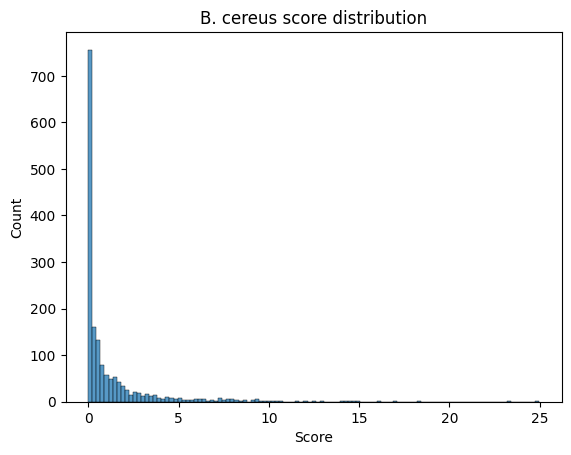

In [13]:
ax = sns.histplot(data=bcereus, x="Score")
ax.set_title("B. cereus score distribution")
bcereus["Score"].describe()

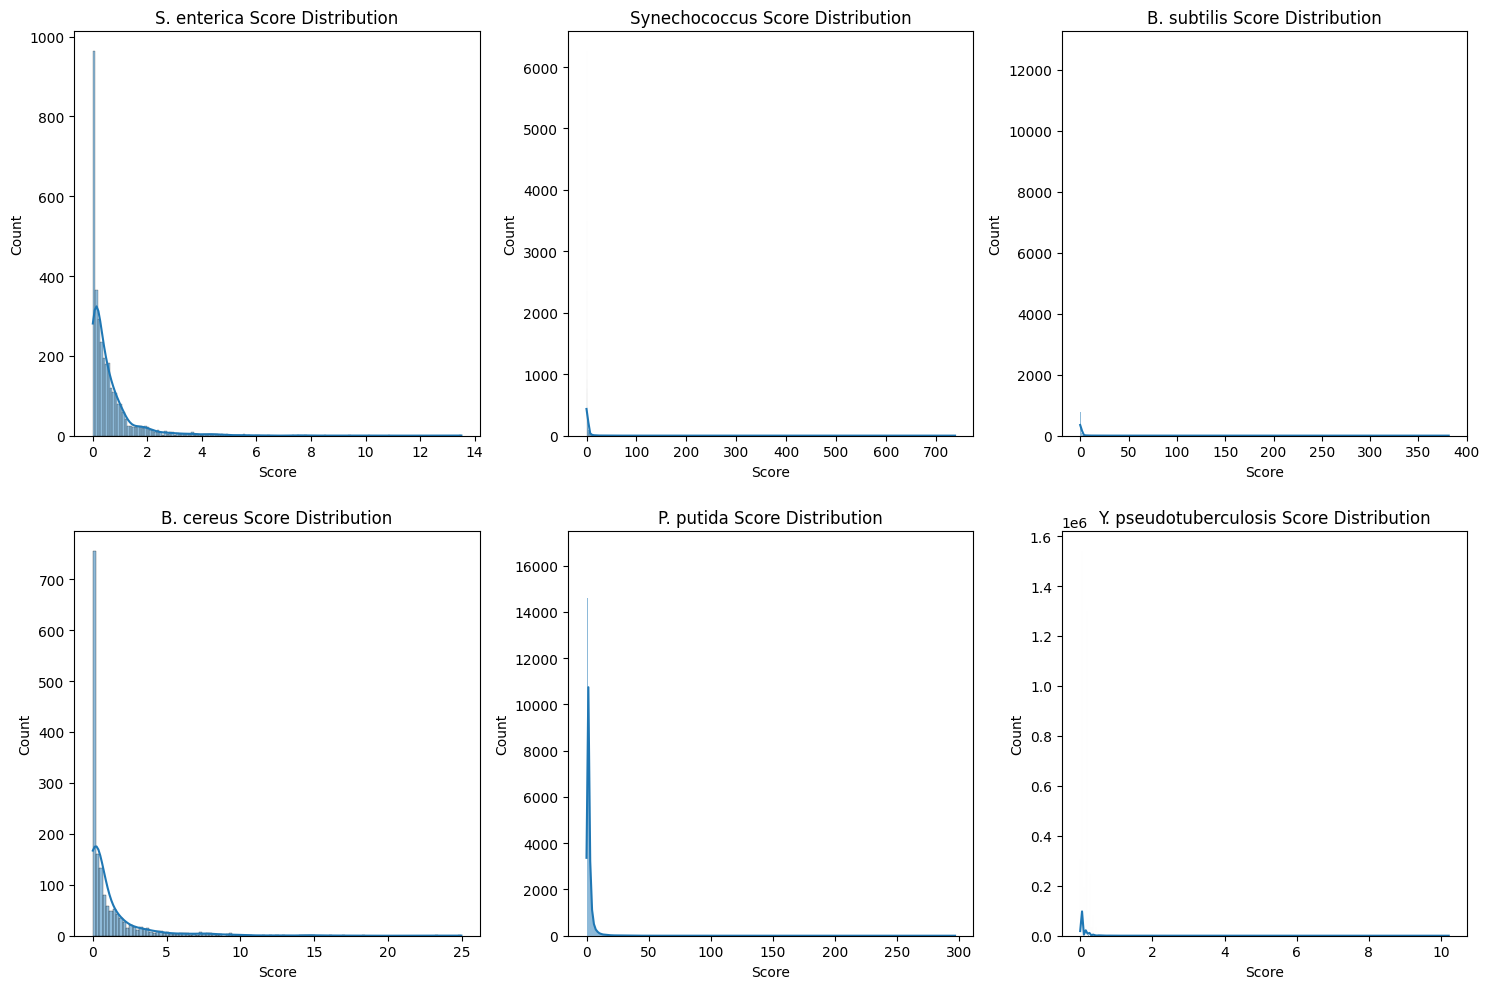

In [8]:
dataframes = [senterica, synechococcus, bsubtilis, bcereus, pputida, ypseudo]
names = ["S. enterica", "Synechococcus", "B. subtilis", "B. cereus", "P. putida", "Y. pseudotuberculosis"]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes = axes.flatten()

for i, df in enumerate(dataframes):
    sns.histplot(data=df, x='Score', kde=True, ax=axes[i])
    axes[i].set_title(f'{names[i]} Score Distribution')



plt.tight_layout()
plt.show()


In [9]:
for df in dataframes:
    print(df.head())
    print(df["Score"].describe())

                                                 Seq     Species     Method  \
0  AAAAGGCTTTTATAGACTTGAAAATGTTTTTCCCGTCCCTATGTAG...  s_enterica  SHAPE-seq   
1  AAAGGCTTTTATAGACTTGAAAATGTTTTTCCCGTCCCTATGTAGT...  s_enterica  SHAPE-seq   
2  AAGGCTTTTATAGACTTGAAAATGTTTTTCCCGTCCCTATGTAGTC...  s_enterica  SHAPE-seq   
3  AGGCTTTTATAGACTTGAAAATGTTTTTCCCGTCCCTATGTAGTCA...  s_enterica  SHAPE-seq   
4  GGCTTTTATAGACTTGAAAATGTTTTTCCCGTCCCTATGTAGTCAG...  s_enterica  SHAPE-seq   

  Reagent  Temp Condition Specificity    Score    Coord  Study ID  \
0     1M7    42   in_vivo    targeted  0.00000  1335447         1   
1     1M7    42   in_vivo    targeted  0.18902  1335448         1   
2     1M7    42   in_vivo    targeted  1.16217  1335449         1   
3     1M7    42   in_vivo    targeted  0.29053  1335450         1   
4     1M7    42   in_vivo    targeted  0.16328  1335451         1   

                 Paper  
0  Biochemistry (2017)  
1  Biochemistry (2017)  
2  Biochemistry (2017)  
3  Biochem

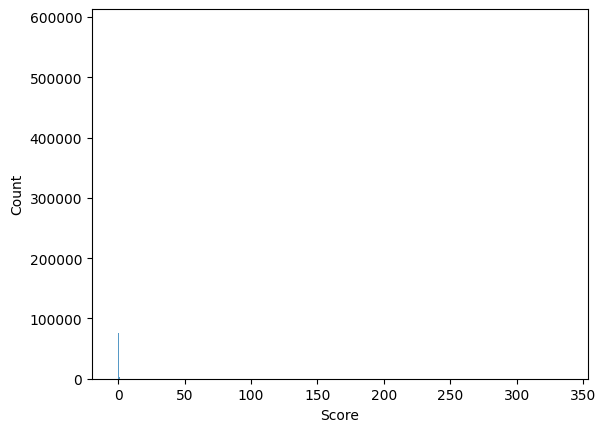

In [10]:
sns.histplot(data=ecoli, x='Score')
axes[i].set_title(f'{df} Score Distribution')
plt.show()


In [11]:
ecoli["Score"].describe()

count    7.136996e+06
mean     4.154989e-01
std      7.871817e-01
min     -2.700000e+00
25%      1.000000e-01
50%      2.900000e-01
75%      5.700000e-01
max      3.364830e+02
Name: Score, dtype: float64

/tmp/ipykernel_96361/1836107282.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=ecoli, x='Category', palette='viridis')


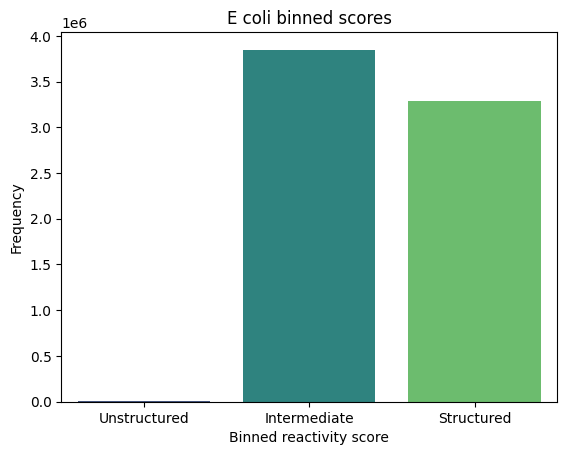

In [17]:
#structure scores are binned into {unstructured, intermediate, structured}
#following the R function bin_SHAPE_data (min=-0.7, max=0.33)

import math
negative_infinity = float('-inf')
infinity = float('inf')

bin_edges = [negative_infinity, -0.7, 0.33, infinity]
bin_labels = ["Unstructured", "Intermediate", "Structured"]

#Categorising data for equal widths of hist plot
ecoli['Category'] = pd.cut(ecoli['Score'], bins=bin_edges, labels=bin_labels, include_lowest=True)

sns.countplot(data=ecoli, x='Category', palette='viridis')

plt.xlabel('Binned reactivity score')
plt.ylabel('Frequency')
plt.title('E coli binned scores')
plt.show()

In [ ]:
#Categorising data for equal widths of hist plot
ecoli['Category'] = pd.cut(ecoli['Score'], bins=bin_edges, labels=bin_labels, include_lowest=True)

sns.countplot(data=ecoli, x='Category', palette='viridis')

plt.xlabel('Binned reactivity score')
plt.ylabel('Frequency')
plt.title('E coli binned scores')
plt.show()

In [21]:
ecoli["Paper"].value_counts()

Paper
eLife (2017)                                    5806082
Cell (2018)                                     1007861
Science (2016)                                   256460
Nucleic_Acids_Research (2021)                     60365
RNA_Biology (2022)                                 4518
Molecular_Cell (2021)                               912
Nature_Structural___Molecular_Biology (2016)        798
Name: count, dtype: int64

/tmp/ipykernel_96361/385861990.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=mustoecategories, palette='viridis')


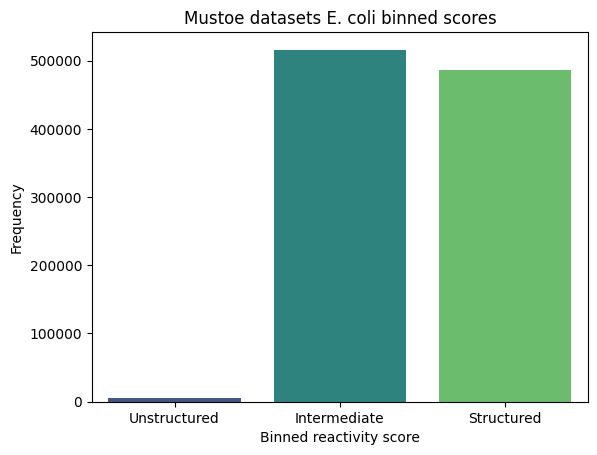

In [24]:
#Now, ONLY looking at the mustoe data that deepshape.ecoli is trained on
mustoescores = ecoli[ecoli["Paper"] == "Cell (2018)"]["Score"]

#Categorising data for equal widths of hist plot
mustoecategories = pd.cut(mustoescores, bins=bin_edges, labels=bin_labels, include_lowest=True)

sns.countplot(x=mustoecategories, palette='viridis')

plt.xlabel('Binned reactivity score')
plt.ylabel('Frequency')
plt.title('Mustoe datasets E. coli binned scores')
plt.show()

/tmp/ipykernel_96361/1781932489.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Category', palette='viridis', ax=axes[i])
/tmp/ipykernel_96361/1781932489.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Category', palette='viridis', ax=axes[i])
/tmp/ipykernel_96361/1781932489.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Category', palette='viridis', ax=axes[i])
/tmp/ipykernel_96361/1781932489.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remo

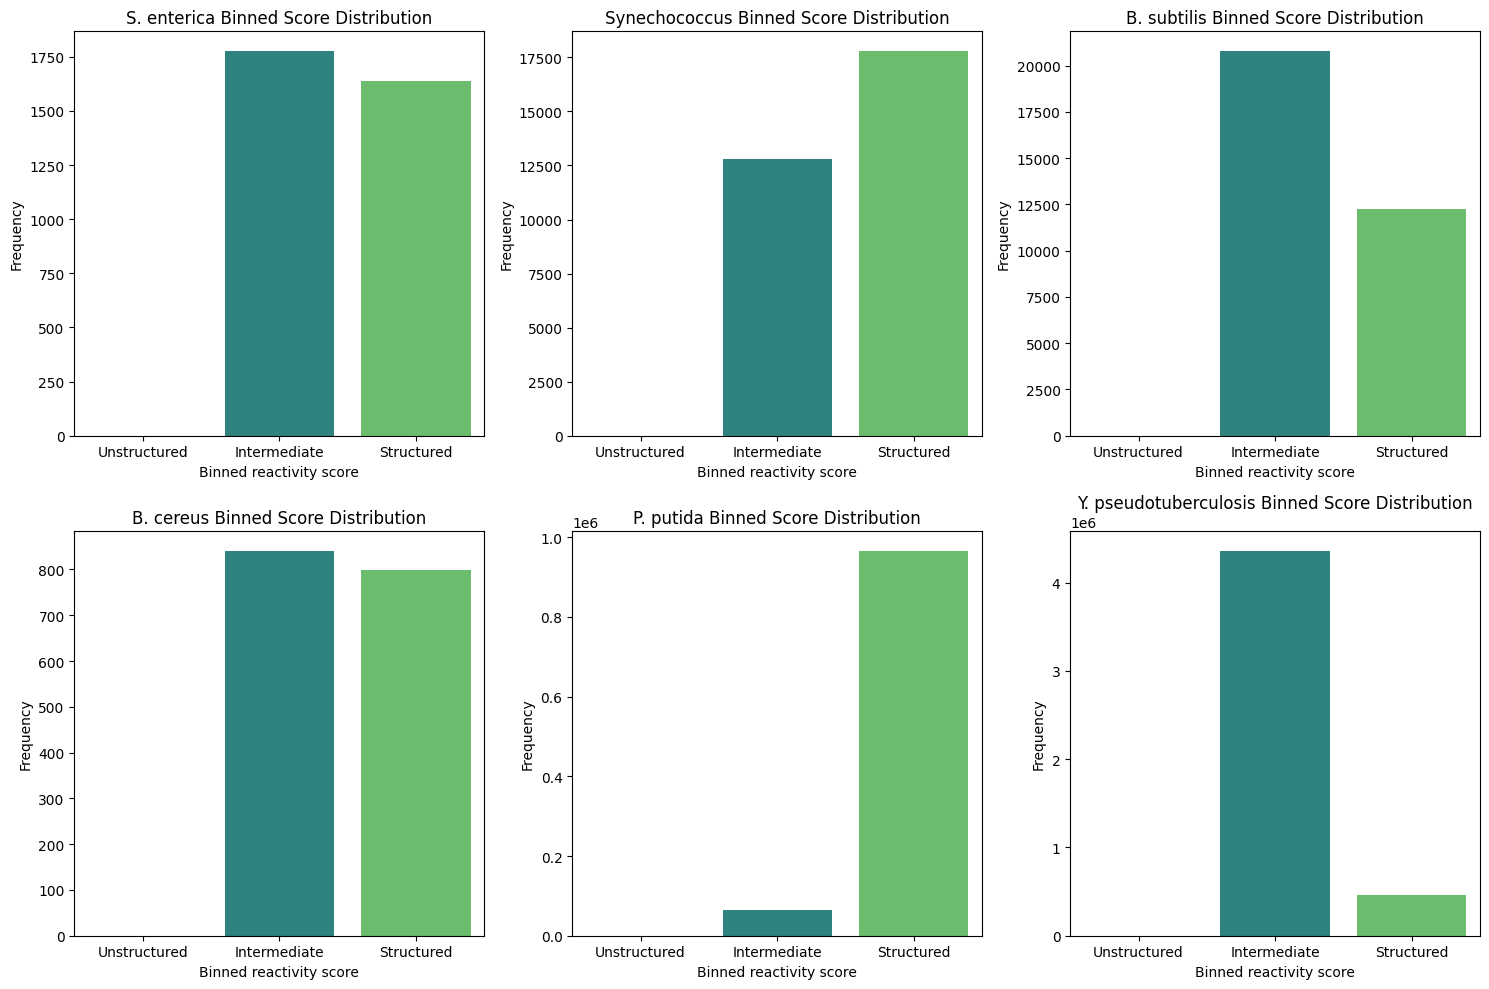

In [18]:
#dataframes = [senterica, synechococcus, bsubtilis, bcereus, pputida, ypseudo]
#names = ["S. enterica", "Synechococcus", "B. subtilis", "B. cereus", "P. putida", "Y. pseudotuberculosis"]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes = axes.flatten()

for i, df in enumerate(dataframes):
    df['Category'] = pd.cut(df['Score'], bins=bin_edges, labels=bin_labels, include_lowest=True)
    sns.countplot(data=df, x='Category', palette='viridis', ax=axes[i])

    axes[i].set_xlabel('Binned reactivity score')
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f'{names[i]} Binned Score Distribution')


plt.tight_layout()
plt.show()


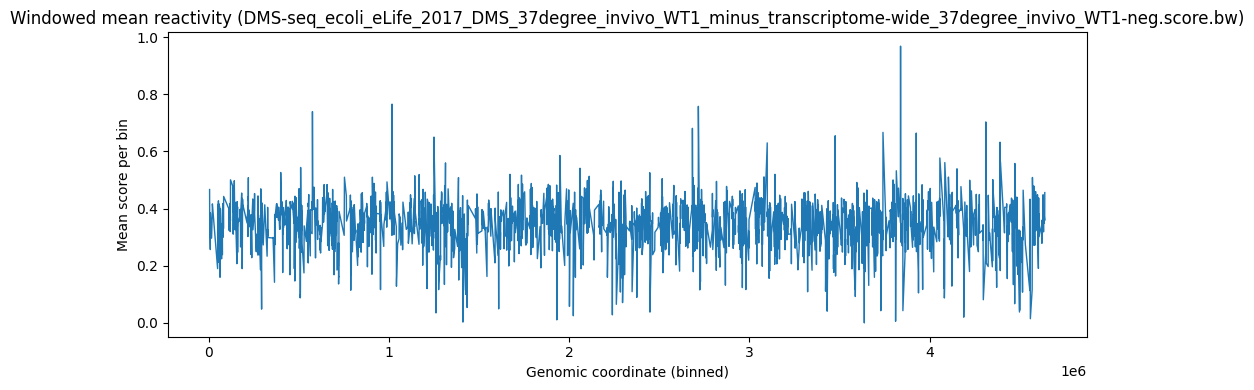

In [ ]:
chosen = samples_subset[0] if samples_subset else tuple_cols[0]
w = 500  # window size
samp = df_long[df_long["sample"] == chosen].dropna(subset=["pos","score"]).copy()
samp["bin"] = (samp["pos"] // w).astype(int)
profile = samp.groupby("bin")["score"].mean().reset_index()
profile["coord"] = profile["bin"] * w

plt.figure(figsize=(10,4))
plt.plot(profile["coord"], profile["score"], linewidth=1)
plt.xlabel("Genomic coordinate (binned)")
plt.ylabel("Mean score per bin")
plt.title(f"Windowed mean reactivity ({chosen})")
plt.tight_layout()
plt.show()


In [ ]:
s1, s2 = samples_subset[:2] if len(samples_subset) >= 2 else tuple_cols[:2]

a = df_long[df_long["sample"] == s1][["pos","score"]].dropna()
b = df_long[df_long["sample"] == s2][["pos","score"]].dropna()

merged = a.merge(b, on="pos", suffixes=(f"_{s1}", f"_{s2}"))
print(f"Common loci between\n - {s1}\n - {s2}\n= {len(merged)}")

if len(merged) > 2:
    rho = merged[f"score_{s1}"].corr(merged[f"score_{s2}"], method="spearman")
    print(f"Spearman rho: {rho:.3f}")

    plt.figure(figsize=(5,5))
    plt.scatter(merged[f"score_{s1}"], merged[f"score_{s2}"], s=6, alpha=0.5)
    plt.xlabel(s1)
    plt.ylabel(s2)
    plt.title(f"Matched-locus correlation\nSpearman ρ={rho:.2f}")
    plt.tight_layout()
    plt.show()


Common loci between
 - DMS-seq_ecoli_eLife_2017_DMS_37degree_invivo_WT1_minus_transcriptome-wide_37degree_invivo_WT1-neg.score.bw
 - DMS-seq_ecoli_eLife_2017_DMS_37degree_invivo_WT1_plus_transcriptome-wide_37degree_invivo_WT1-pos.score.bw
= 0


/tmp/ipykernel_37813/2845826807.py:16: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


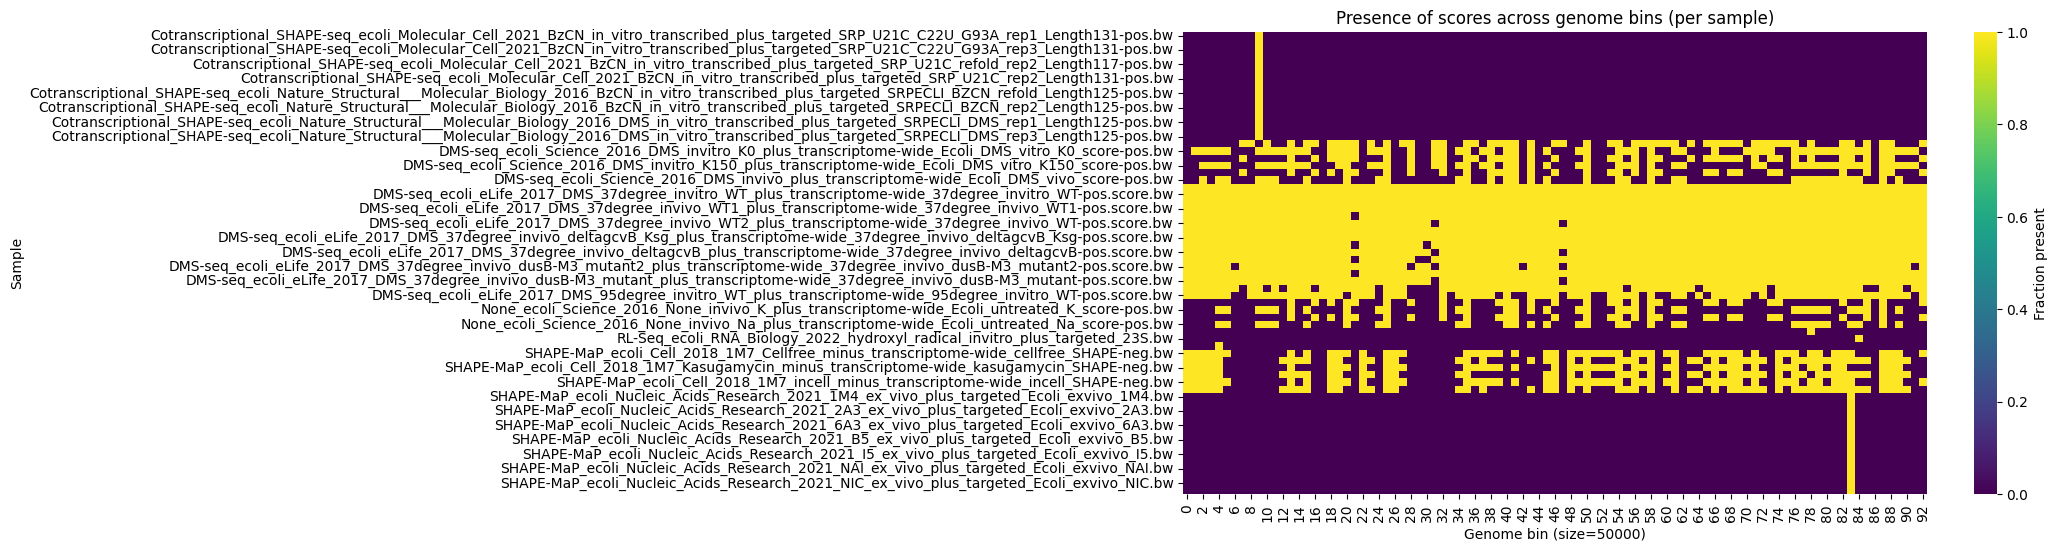

In [ ]:
bin_size = 50000  # coarse bins for a transcriptome-scale view
tmp = df_long.dropna(subset=["pos"]).copy()
tmp["bin"] = (tmp["pos"] // bin_size).astype(int)
# presence = not missing -> 1 if we *have* a score
tmp["present"] = (~tmp["score"].isna()).astype(int)

heat = (tmp.groupby(["sample","bin"])["present"]
            .mean()  # fraction present in bin
            .unstack(fill_value=0))

plt.figure(figsize=(12,6))
sns.heatmap(heat, cmap="viridis", cbar_kws={"label": "Fraction present"})
plt.title("Presence of scores across genome bins (per sample)")
plt.xlabel(f"Genome bin (size={bin_size})")
plt.ylabel("Sample")
plt.tight_layout()
plt.show()
